# Welch vs glmGamPoi (SE and lfc) — DMSO batch1 (Option A)

For 500 perturbations sampled from
`/processed_datasets/VCI/ChemoGenetic_H1/8cmpd_set1/Full/PertQC_CytoGMM/`
`DualGuideOnly_ntgUPM5/DMSO/scanpy/ad_gene_guide_complete.gene.h5ad` (raw
counts) — stratified across 10 log-spaced cell-count bins — we compare:

- **Welch SE / lfc** — `sqrt(var_p/n_p + var_c/n_c)` and
  `mean(log1p(x_p)) - mean(log1p(x_c))` on the **log1p-normalised**
  counterpart adata at
  `/processed_datasets/VCI/ChemoGenetic_H1_Basak/DMSO_round2/DMSO_round2.h5ad`.
- **glmGamPoi SE / lfc** — SE and contrast log fold-change from a per-perturbation
  Gamma-Poisson GLM on **raw counts**; SE computed as `|lfc|/sqrt(f_statistic)`.

Same cells in both estimators (cell IDs aligned and identical between the
two h5ads). Same fixed shared non-targeting control subsample. Both lfc
columns are in **natural-log units of the mean ratio** (Welch via log1p
≈ ln-ratio for moderately-expressed genes; glmGamPoi via log link).

All comparison plots are colored by the gene's mean log1p expression in
the 10 000 shared NT control cells (`§1b`), so we can read the SE/lfc
relationship by gene expression level.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

OUT_DIR = Path("/home/beraslan/Projects/ChemoGeneticScreens/Notes/welch_vs_glmgampoi_n10k")
WELCH   = OUT_DIR / "welch_se_long.parquet"
GLM     = OUT_DIR / "glmgampoi_long.csv"
PERTS   = OUT_DIR / "selected_perts.csv"
print(f"Welch parquet : {WELCH}  ({WELCH.stat().st_size/1e6:.1f} MB)" if WELCH.exists() else f"missing {WELCH}")
print(f"glm csv       : {GLM}    ({GLM.stat().st_size/1e6:.1f} MB)"   if GLM.exists()   else f"missing {GLM}")

Welch parquet : /home/beraslan/Projects/ChemoGeneticScreens/Notes/welch_vs_glmgampoi_n10k/welch_se_long.parquet  (161.9 MB)
glm csv       : /home/beraslan/Projects/ChemoGeneticScreens/Notes/welch_vs_glmgampoi_n10k/glmgampoi_long.csv    (1077.8 MB)


## 1. Load and align

In [2]:
welch = pd.read_parquet(WELCH)
glm   = pd.read_csv(GLM)


In [3]:

print(f"welch rows: {len(welch):,}  cols: {list(welch.columns)}")
print(f"glm   rows: {len(glm):,}    cols: {list(glm.columns)}")

joined = pd.merge(
    welch.rename(columns={"se": "se_welch", "mean_diff": "lfc_welch"}),
    glm.rename(columns={"se_lfc": "se_glm", "lfc": "lfc_glm",
                          "n_pert": "n_pert_glm", "n_ctrl": "n_ctrl_glm"}),
    on=["perturbation", "gene"], how="inner",
)
joined = joined.replace([np.inf, -np.inf], np.nan)\
                 .dropna(subset=["se_welch", "se_glm"])
print(f"merged rows : {len(joined):,}")
print(joined.head(3).to_string())


welch rows: 9,077,000  cols: ['perturbation', 'gene', 'mean_diff', 'se', 'n_pert', 'n_ctrl']
glm   rows: 9,077,000    cols: ['gene', 'perturbation', 'n_pert', 'n_ctrl', 'lfc', 'se_lfc', 'pval', 'adj_pval', 'f_statistic', 'df1', 'df2']
merged rows : 8,607,572
  perturbation    gene  lfc_welch  se_welch  n_pert  n_ctrl  n_pert_glm  n_ctrl_glm   lfc_glm    se_glm      pval  adj_pval  f_statistic  df1           df2
0         SOX3  TSPAN6  -0.264968  0.142422       8   10000           8       10000 -0.451653  0.218701  0.038934       1.0     4.264873    1  10054.404029
1         SOX3    TNMD   0.105660  0.114936       8   10000           8       10000  1.896980  1.185947  0.109730       1.0     2.558558    1  10054.404029
2         SOX3    DPM1  -0.306850  0.128756       8   10000           8       10000 -0.665358  0.267082  0.012747       1.0     6.206135    1  10054.404029


## 1b. Gene mean expression in NT control cells (used as color throughout)

Load the 10 000 shared NT cells from the new run, slice the log1p-normalised
adata, and compute the per-gene mean log1p expression. We merge this into
`joined` as `mean_ctrl_log1p` and use it as the color variable in all
subsequent (pert, gene) plots.

In [4]:
import anndata as ad

CTRL_IDS_10K = Path("/home/beraslan/Projects/ChemoGeneticScreens/Notes/welch_vs_glmgampoi_n10k/shared_nt_cell_ids.csv")
LOG1P_ADATA  = Path("/processed_datasets/VCI/ChemoGenetic_H1_Basak/DMSO_round2/DMSO_round2.h5ad")

ctrl_ids = pd.read_csv(CTRL_IDS_10K)["cell_id"].astype(str).tolist()
print(f"loaded {len(ctrl_ids):,} shared NT cell IDs")

a_log = ad.read_h5ad(LOG1P_ADATA)
print(f"log1p adata: {a_log.shape}")

keep = a_log.obs_names.isin(ctrl_ids)
print(f"matched cells: {keep.sum():,}")
mean_ctrl = np.asarray(a_log.X[keep].mean(axis=0)).ravel()

gene_mean = pd.DataFrame({"gene": a_log.var_names.to_numpy(),
                          "mean_ctrl_log1p": mean_ctrl})
print(f"per-gene mean log1p: n={len(gene_mean):,}; "
      f"min={gene_mean['mean_ctrl_log1p'].min():.3f}, "
      f"median={gene_mean['mean_ctrl_log1p'].median():.3f}, "
      f"max={gene_mean['mean_ctrl_log1p'].max():.3f}")
del a_log  # free memory

joined = joined.merge(gene_mean, on="gene", how="left")
joined.head(3)

loaded 10,000 shared NT cell IDs
log1p adata: (1694712, 18154)
matched cells: 10,000
per-gene mean log1p: n=18,154; min=0.000, median=0.237, max=5.219


,perturbation,gene,lfc_welch,se_welch,n_pert,n_ctrl,n_pert_glm,n_ctrl_glm,lfc_glm,se_glm,pval,adj_pval,f_statistic,df1,df2,mean_ctrl_log1p
0,SOX3,TSPAN6,-0.264968,0.142422,8,10000,8,10000,-0.451653,0.218701,0.038934,1.0,4.264873,1,10054.404029,2.019485
1,SOX3,TNMD,0.105660,0.114936,8,10000,8,10000,1.896980,1.185947,0.109730,1.0,2.558558,1,10054.404029,0.048929
2,SOX3,DPM1,-0.306850,0.128756,8,10000,8,10000,-0.665358,0.267082,0.012747,1.0,6.206135,1,10054.404029,1.635952


## 2. Global SE comparison — colored by gene control-mean expression

Hexbin where each cell is colored by the **median `mean_ctrl_log1p` of the
points falling in it**, rather than count density. This reveals the
expression-level structure of the SE relationship without subsampling.

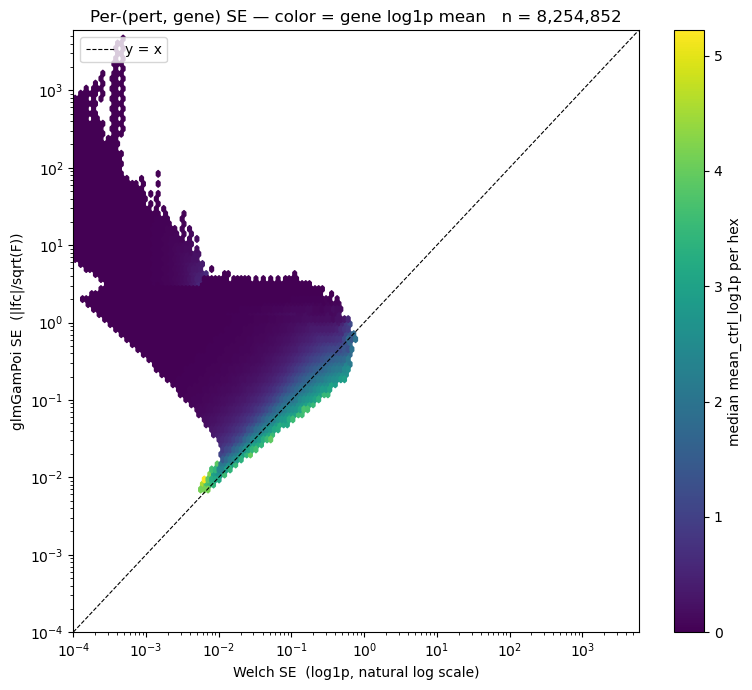

Pearson r (log SE)        = -0.629
Spearman ρ                 = -0.249
median ratio Welch/glm    = 0.185
median Welch SE           = 0.0202
median glmGamPoi SE       = 0.2693


In [5]:
lo = 1e-4
hi = max(joined["se_welch"].max(), joined["se_glm"].max()) * 1.1

m = (joined["se_welch"] > lo) & (joined["se_glm"] > lo) & joined["mean_ctrl_log1p"].notna()

fig, ax = plt.subplots(figsize=(8, 7))
hb = ax.hexbin(joined.loc[m, "se_welch"], joined.loc[m, "se_glm"],
               C=joined.loc[m, "mean_ctrl_log1p"],
               reduce_C_function=np.median,
               xscale="log", yscale="log",
               gridsize=80, mincnt=10, cmap="viridis")
fig.colorbar(hb, ax=ax, label="median mean_ctrl_log1p per hex")
ax.plot([lo, hi], [lo, hi], "k--", lw=0.8, label="y = x")
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel("Welch SE  (log1p, natural log scale)")
ax.set_ylabel("glmGamPoi SE  (|lfc|/sqrt(F))")
ax.set_title(f"Per-(pert, gene) SE — color = gene log1p mean   n = {m.sum():,}")
ax.legend()
plt.tight_layout(); plt.show()

import scipy.stats as st
r_p, _ = st.pearsonr(np.log10(joined.loc[m, "se_welch"]),
                      np.log10(joined.loc[m, "se_glm"]))
r_s, _ = st.spearmanr(joined.loc[m, "se_welch"], joined.loc[m, "se_glm"])
print(f"Pearson r (log SE)        = {r_p:.3f}")
print(f"Spearman ρ                 = {r_s:.3f}")
print(f"median ratio Welch/glm    = {(joined['se_welch'] / joined['se_glm']).median():.3f}")
print(f"median Welch SE           = {joined['se_welch'].median():.4f}")
print(f"median glmGamPoi SE       = {joined['se_glm'].median():.4f}")

## 3. Stratified by `n_pert` (cell count), colored by gene control-mean

Each panel uses the same color encoding as §2 — median `mean_ctrl_log1p`
per hex. If the SE structure depends mostly on gene expression and not on
cell count, the panels should look similar.

(pert, gene) rows per n_bin:
n_bin
2-50         2991683
50-100        842647
100-200      1049298
200-400       860473
400-800       826654
800-1600     1120692
1600-3000     898789


/tmp/ipykernel_564844/193027208.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1]); plt.show()


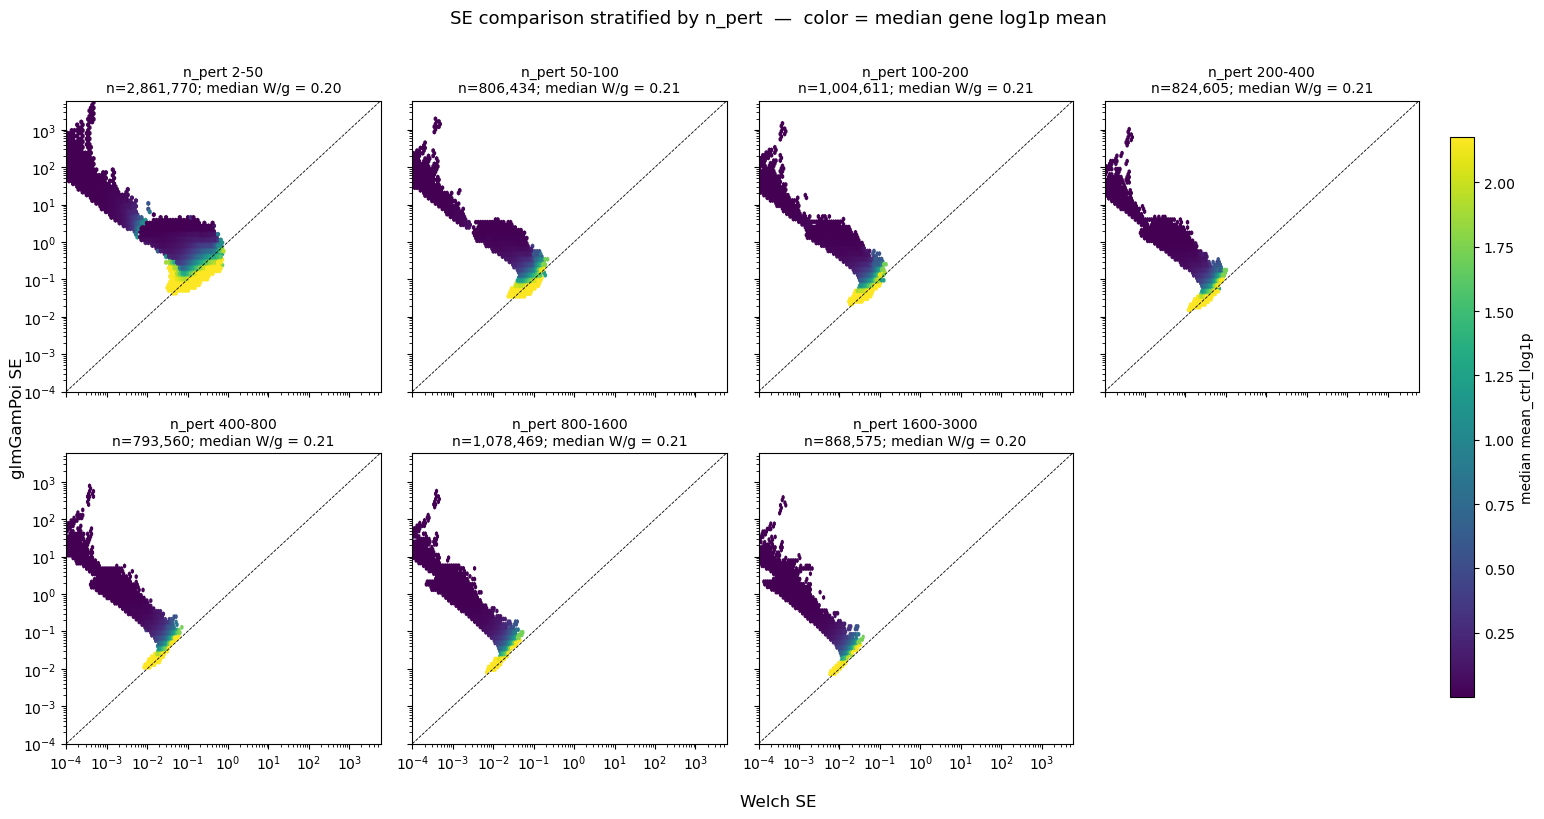

In [6]:
bins = [2, 50, 100, 200, 400, 800, 1600, 3000]
bin_labels = ["2-50", "50-100", "100-200", "200-400",
              "400-800", "800-1600", "1600-3000"]
joined["n_bin"] = pd.cut(joined["n_pert"], bins=bins, labels=bin_labels,
                          include_lowest=True)
print("(pert, gene) rows per n_bin:")
print(joined["n_bin"].value_counts().reindex(bin_labels, fill_value=0).to_string())

n_used = [l for l in bin_labels if (joined["n_bin"] == l).sum() > 0]
n_cols = 4
n_rows = int(np.ceil(len(n_used) / n_cols))
vmin, vmax = joined["mean_ctrl_log1p"].quantile([0.02, 0.98])

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows),
                          sharex=True, sharey=True)
axes = np.array(axes).flatten()
for ax, lab in zip(axes, n_used):
    sub = joined[(joined["n_bin"] == lab) & joined["mean_ctrl_log1p"].notna()
                  & (joined["se_welch"] > lo) & (joined["se_glm"] > lo)]
    if sub.empty:
        ax.set_axis_off(); continue
    hb = ax.hexbin(sub["se_welch"], sub["se_glm"], C=sub["mean_ctrl_log1p"],
                    reduce_C_function=np.median, xscale="log", yscale="log",
                    gridsize=60, mincnt=5, cmap="viridis", vmin=vmin, vmax=vmax)
    ax.plot([lo, hi], [lo, hi], "k--", lw=0.6)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    med_ratio = (sub["se_welch"] / sub["se_glm"]).median()
    ax.set_title(f"n_pert {lab}\nn={len(sub):,}; median W/g = {med_ratio:.2f}",
                  fontsize=10)
for ax in axes[len(n_used):]:
    ax.set_axis_off()
fig.supxlabel("Welch SE", fontsize=12)
fig.supylabel("glmGamPoi SE", fontsize=12)
fig.suptitle("SE comparison stratified by n_pert  —  color = median gene log1p mean",
             fontsize=13, y=1.01)
# single shared colorbar
cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(hb, cax=cax, label="median mean_ctrl_log1p")
plt.tight_layout(rect=[0, 0, 0.91, 1]); plt.show()

## 4. Median SE ratio vs `n_pert`

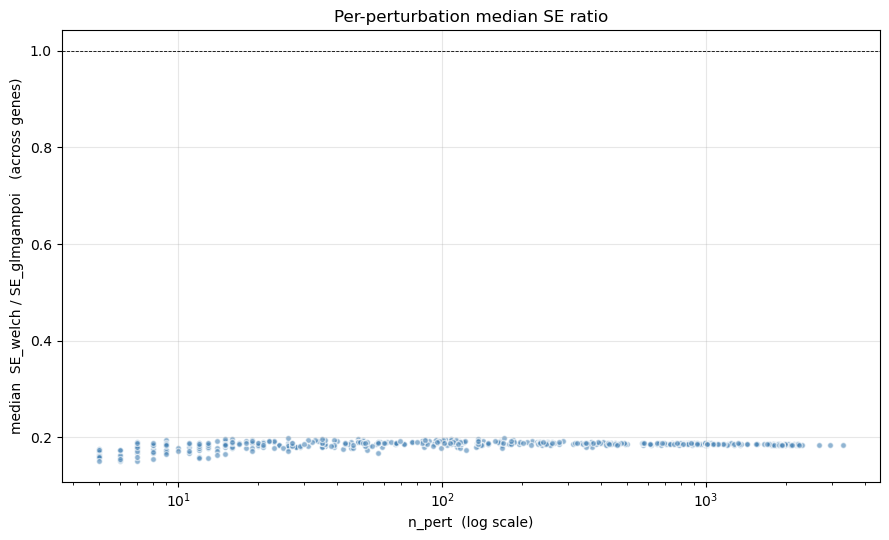

In [7]:
def med_ratio(s):
    return (s / joined.loc[s.index, "se_glm"]).median()

per_pert = (
    joined.groupby("perturbation")
          .agg(n_pert=("n_pert", "first"),
                ratio_med=("se_welch", med_ratio),
                welch_med=("se_welch", "median"),
                glm_med  =("se_glm",   "median"))
          .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(per_pert["n_pert"], per_pert["ratio_med"],
            s=18, alpha=0.6, color="steelblue", edgecolor="white")
ax.axhline(1.0, ls="--", color="black", lw=0.6)
ax.set_xscale("log")
ax.set_xlabel("n_pert  (log scale)")
ax.set_ylabel("median  SE_welch / SE_glmgampoi   (across genes)")
ax.set_title("Per-perturbation median SE ratio")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. logFC comparison — colored by gene control-mean expression

Welch effect = `mean(log1p(x_p)) - mean(log1p(x_c))` on normalised counts;
glmGamPoi `lfc` = natural-log of the mean ratio under the Gamma-Poisson
GLM. For high-mean genes `log1p ≈ ln`, so they should land near y = x;
low-mean genes diverge because log1p compresses while the GLM does not.
glmGamPoi-saturated rows (|lfc| ≥ 10) are excluded.

glmGamPoi saturated rows excluded: 1,492,115 (17.3%)


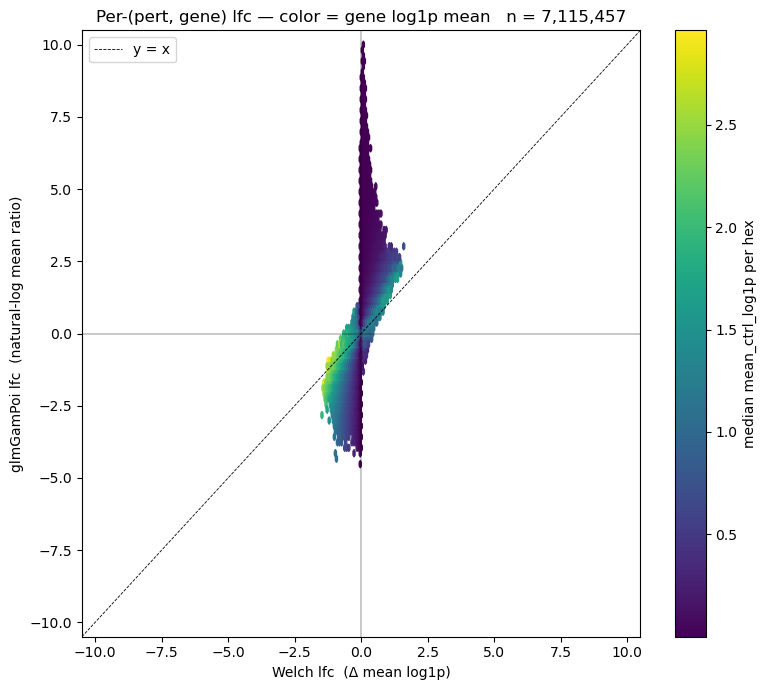

Pearson r  (lfc)         = 0.477
Spearman ρ (lfc)         = 0.782
sign agreement           = 87.9%
median lfc_welch         = -0.0005
median lfc_glm           = +0.0044


In [8]:
sat = joined["lfc_glm"].abs() >= 9.999
print(f"glmGamPoi saturated rows excluded: {sat.sum():,} ({sat.mean()*100:.1f}%)")
unsat = joined[~sat & joined["mean_ctrl_log1p"].notna()]

lim = max(unsat["lfc_welch"].abs().max(), unsat["lfc_glm"].abs().max()) * 1.05

fig, ax = plt.subplots(figsize=(8, 7))
hb = ax.hexbin(unsat["lfc_welch"], unsat["lfc_glm"],
                C=unsat["mean_ctrl_log1p"], reduce_C_function=np.median,
                gridsize=80, mincnt=10, cmap="viridis")
fig.colorbar(hb, ax=ax, label="median mean_ctrl_log1p per hex")
ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.6, label="y = x")
ax.axhline(0, color="k", lw=0.3); ax.axvline(0, color="k", lw=0.3)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("Welch lfc  (Δ mean log1p)")
ax.set_ylabel("glmGamPoi lfc  (natural-log mean ratio)")
ax.set_title(f"Per-(pert, gene) lfc — color = gene log1p mean   n = {len(unsat):,}")
ax.legend()
plt.tight_layout(); plt.show()

r_p, _ = st.pearsonr(unsat["lfc_welch"], unsat["lfc_glm"])
r_s, _ = st.spearmanr(unsat["lfc_welch"], unsat["lfc_glm"])
sign_agree = (np.sign(unsat['lfc_welch']) == np.sign(unsat['lfc_glm'])).mean()
print(f"Pearson r  (lfc)         = {r_p:.3f}")
print(f"Spearman ρ (lfc)         = {r_s:.3f}")
print(f"sign agreement           = {sign_agree*100:.1f}%")
print(f"median lfc_welch         = {unsat['lfc_welch'].median():+.4f}")
print(f"median lfc_glm           = {unsat['lfc_glm'].median():+.4f}")

## 7. Per-gene aggregate view

For each gene, take the median Welch SE / glm SE / Welch lfc / glm lfc
across the perturbations. Scatter at gene level, colored by control mean.
Quintile diagnostic shows how the SE ratio scales with expression.

per-gene rows: 17,192


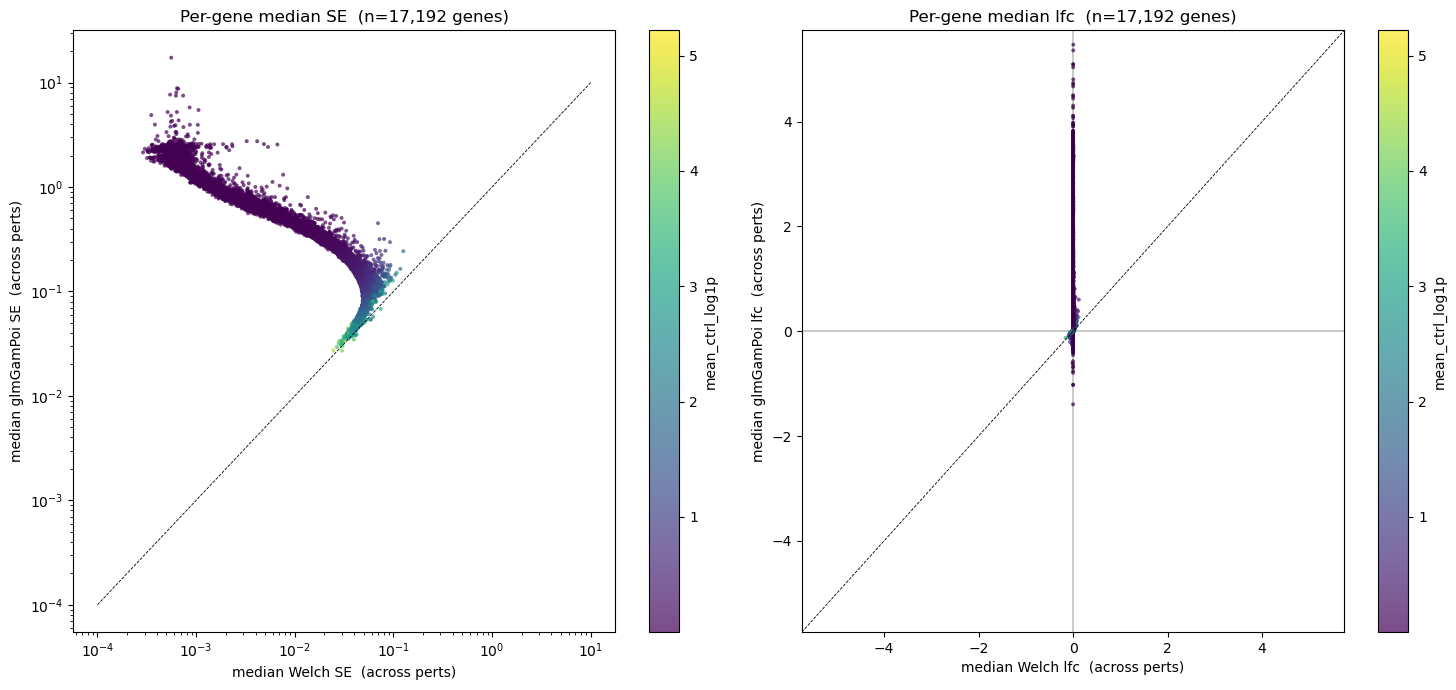

=== median per-gene SE Welch/glm by control-expression quintile ===
        n_genes  expr_mid  med_welch  med_glm  med_ratio
expr_q                                                  
Q1         3439    0.0007     0.0009   1.4001     0.0006
Q2         3438    0.0423     0.0117   0.4234     0.0279
Q3         3438    0.2848     0.0360   0.1953     0.1856
Q4         3438    0.6921     0.0492   0.1192     0.4145
Q5         3439    1.4119     0.0508   0.0760     0.6867


In [9]:
per_gene = (unsat
    .groupby("gene")
    .agg(n_perts      = ("perturbation", "nunique"),
         med_se_welch = ("se_welch", "median"),
         med_se_glm   = ("se_glm",   "median"),
         med_lfc_welch= ("lfc_welch","median"),
         med_lfc_glm  = ("lfc_glm",  "median"))
    .reset_index()
    .merge(gene_mean, on="gene", how="left")
    .dropna(subset=["mean_ctrl_log1p", "med_se_welch", "med_se_glm"])
)
print(f"per-gene rows: {len(per_gene):,}")

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# SE per-gene
ax = axes[0]
m = (per_gene["med_se_welch"] > 0) & (per_gene["med_se_glm"] > 0)
sc = ax.scatter(per_gene.loc[m, "med_se_welch"], per_gene.loc[m, "med_se_glm"],
                c=per_gene.loc[m, "mean_ctrl_log1p"], cmap="viridis",
                s=8, alpha=0.7, linewidths=0)
ax.set_xscale("log"); ax.set_yscale("log")
ax.plot([1e-4, 1e1], [1e-4, 1e1], "k--", lw=0.6)
ax.set_xlabel("median Welch SE  (across perts)")
ax.set_ylabel("median glmGamPoi SE  (across perts)")
ax.set_title(f"Per-gene median SE  (n={m.sum():,} genes)")
fig.colorbar(sc, ax=ax, label="mean_ctrl_log1p")

# lfc per-gene
ax = axes[1]
sc = ax.scatter(per_gene["med_lfc_welch"], per_gene["med_lfc_glm"],
                c=per_gene["mean_ctrl_log1p"], cmap="viridis",
                s=8, alpha=0.7, linewidths=0)
lim = max(per_gene["med_lfc_welch"].abs().max(), per_gene["med_lfc_glm"].abs().max())*1.05
ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.6)
ax.axhline(0, color="k", lw=0.3); ax.axvline(0, color="k", lw=0.3)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("median Welch lfc  (across perts)")
ax.set_ylabel("median glmGamPoi lfc  (across perts)")
ax.set_title(f"Per-gene median lfc  (n={len(per_gene):,} genes)")
fig.colorbar(sc, ax=ax, label="mean_ctrl_log1p")

plt.tight_layout(); plt.show()

per_gene["expr_q"] = pd.qcut(per_gene["mean_ctrl_log1p"], q=5,
                              labels=[f"Q{i+1}" for i in range(5)])
per_gene["se_ratio"] = per_gene["med_se_welch"] / per_gene["med_se_glm"]
diag = per_gene.groupby("expr_q", observed=True).agg(
    n_genes   = ("gene", "size"),
    expr_mid  = ("mean_ctrl_log1p", "median"),
    med_welch = ("med_se_welch", "median"),
    med_glm   = ("med_se_glm",   "median"),
    med_ratio = ("se_ratio",     "median"),
).round(4)
print("=== median per-gene SE Welch/glm by control-expression quintile ===")
print(diag.to_string())

## 8. # of DE genes above |lfc| threshold — does glmGamPoi show the low-n inflation?

In `06_InspectDMSOReplicateDiscrepancy.ipynb` we see that for ashr-shrunk
posterior |β|, perts with fewer cells call **more** DE genes at any τ —
the heavy-tail/noise effect. Here we replicate that view directly on the
two unshrunk lfc estimates (Welch and glmGamPoi) over the same 204
perturbations. If glmGamPoi's count-based, GLM-derived lfc is robust to
small-n inflation we'd expect its curves to flatten; if not, both methods
should show the same low-n elevation.

In [10]:
# Build a long-format table: per (pert, threshold) → n_sig_welch, n_sig_glm,
# n_intersection. We use sorted |lfc| arrays + searchsorted so each pert
# is processed in O(g log g + len(thresholds) * g).

bins_npert = [2, 50, 100, 200, 400, 800, 1600, 3000]
bin_labels_npert = ["2-50", "50-100", "100-200", "200-400",
                     "400-800", "800-1600", "1600-3000"]
if "n_bin" not in joined.columns:
    joined["n_bin"] = pd.cut(joined["n_pert"], bins=bins_npert,
                              labels=bin_labels_npert, include_lowest=True)

# log-spaced thresholds; τ = 0 first so "all genes" baseline is captured
thresholds = np.concatenate([[0.0],
                              np.logspace(np.log10(0.01), np.log10(3.0), 40)])
print(f"thresholds: {thresholds[0]:.3f} → {thresholds[-1]:.3f} (n={len(thresholds)})")

parts = []
g = joined.groupby("perturbation", sort=False)
for pert, sub in g:
    aw = np.sort(np.abs(sub["lfc_welch"].values))
    ag = np.sort(np.abs(sub["lfc_glm"].values))
    n_sig_w = len(aw) - np.searchsorted(aw, thresholds, side="right")
    n_sig_g = len(ag) - np.searchsorted(ag, thresholds, side="right")
    # intersection: joint count via broadcast (small inner loop in C)
    abs_w = np.abs(sub["lfc_welch"].values)
    abs_g = np.abs(sub["lfc_glm"].values)
    mask_w = abs_w[None, :] > thresholds[:, None]
    mask_g = abs_g[None, :] > thresholds[:, None]
    n_inter = (mask_w & mask_g).sum(axis=1)
    nbin = sub["n_bin"].iloc[0]
    n_p  = int(sub["n_pert"].iloc[0])
    for i, tau in enumerate(thresholds):
        parts.append({"perturbation": pert,
                      "n_bin":        nbin,
                      "n_pert":       n_p,
                      "threshold":    float(tau),
                      "n_sig_welch":  int(n_sig_w[i]),
                      "n_sig_glm":    int(n_sig_g[i]),
                      "n_intersection": int(n_inter[i])})
n_sig_long = pd.DataFrame(parts)
print(f"long table rows: {len(n_sig_long):,}  "
      f"({n_sig_long['perturbation'].nunique()} perts × {len(thresholds)} thresholds)")
print("perts per n_bin:")
print(n_sig_long.drop_duplicates("perturbation")["n_bin"]
       .value_counts().reindex(bin_labels_npert, fill_value=0).to_string())

thresholds: 0.000 → 3.000 (n=41)
long table rows: 20,500  (500 perts × 41 thresholds)
perts per n_bin:
n_bin
2-50         174
50-100        49
100-200       61
200-400       50
400-800       48
800-1600      65
1600-3000     52


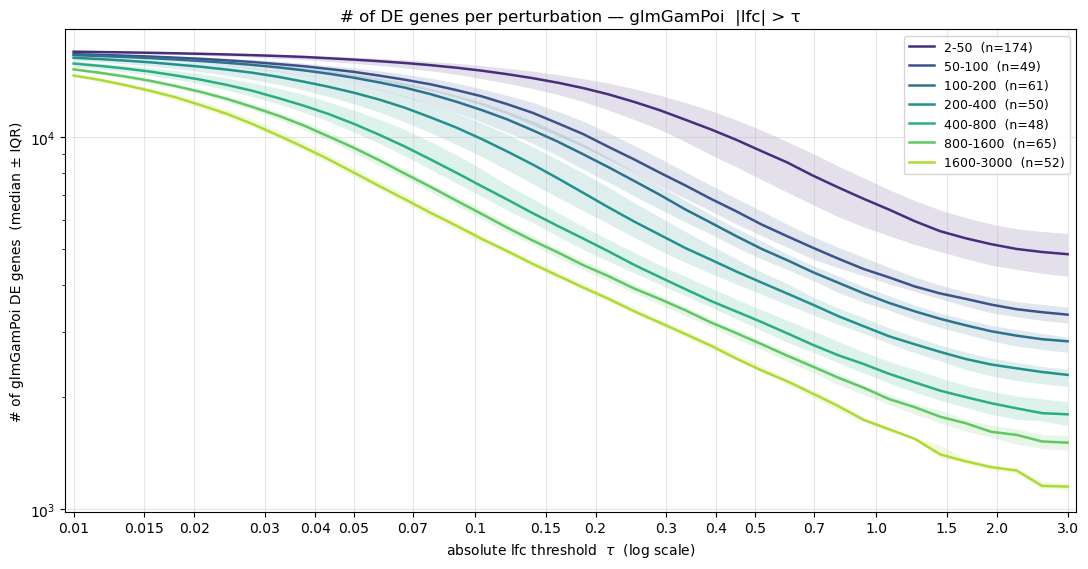

In [11]:
# Plot helper — same style as 06_InspectDMSOReplicateDiscrepancy.ipynb.

_LOG_TICKS = np.array([
    0.005, 0.007,
    0.01,  0.015, 0.02, 0.03, 0.04, 0.05, 0.07,
    0.10,  0.15,  0.20, 0.30, 0.40, 0.50, 0.70,
    1.00,  1.50,  2.00, 3.00, 4.00, 5.00, 7.00,
    10.0,  15.0,  20.0,
])

def _fmt_tick(x):
    if x >= 10: return f"{x:.0f}"
    if x >= 1:  return f"{x:.1f}"
    return f"{x:g}"


def plot_n_sig_vs_threshold(long_df, value_col, *, ax=None,
                             use_median=True, ci=(25, 75),
                             ylabel=None, title=None, logy=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(11, 5.8))
    palette = sns.color_palette("viridis", n_colors=len(bin_labels_npert))
    agg_centre = "median" if use_median else "mean"
    for color, lab in zip(palette, bin_labels_npert):
        sub = long_df[(long_df["n_bin"] == lab) & (long_df["threshold"] > 0)]
        if sub.empty:
            continue
        g = sub.groupby("threshold")[value_col]
        centre = g.median() if use_median else g.mean()
        lo = g.quantile(ci[0] / 100)
        hi = g.quantile(ci[1] / 100)
        n = sub["perturbation"].nunique()
        ax.plot(centre.index, centre.values, color=color, lw=1.8,
                label=f"{lab}  (n={n})")
        ax.fill_between(centre.index, lo.values, hi.values,
                         color=color, alpha=0.15, linewidth=0)

    x_lo = float(long_df.loc[long_df["threshold"] > 0, "threshold"].min())
    x_hi = float(long_df["threshold"].max())
    ax.set_xscale("log")
    ax.set_xlim(x_lo * 0.95, x_hi * 1.05)
    xt = _LOG_TICKS[(_LOG_TICKS >= x_lo) & (_LOG_TICKS <= x_hi)]
    ax.set_xticks(xt)
    ax.set_xticklabels([_fmt_tick(t) for t in xt], rotation=0)
    ax.minorticks_off()
    ax.set_xlabel(r"absolute lfc threshold  $\tau$  (log scale)")
    ax.set_ylabel(ylabel if ylabel is not None
                   else f"{value_col}  ({agg_centre} \u00b1 IQR)")
    ax.set_title(title if title is not None else value_col)
    ax.legend(loc="upper right", fontsize=9, frameon=True)
    if logy:
        ax.set_yscale("log")
    ax.grid(alpha=0.3, which="major")
    return ax


# --- glmGamPoi ---
fig, ax = plt.subplots(figsize=(11, 5.8))
plot_n_sig_vs_threshold(
    n_sig_long, value_col="n_sig_glm", ax=ax,
    ylabel="# of glmGamPoi DE genes  (median \u00b1 IQR)",
    title="# of DE genes per perturbation — glmGamPoi  |lfc| > τ",
    logy=True,
)
fig.tight_layout(); plt.show()

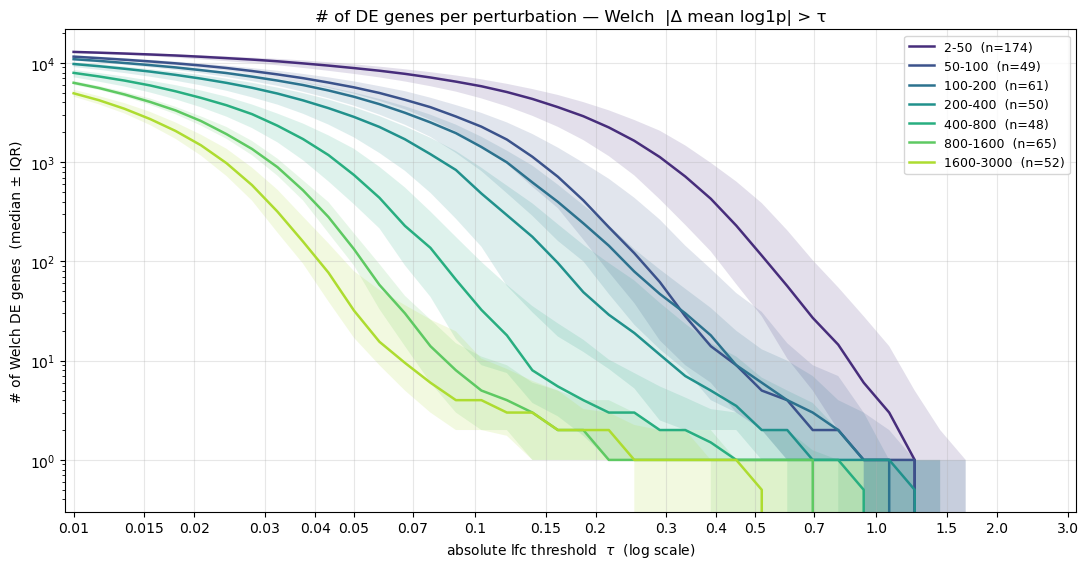

In [12]:
# --- Welch ---
fig, ax = plt.subplots(figsize=(11, 5.8))
plot_n_sig_vs_threshold(
    n_sig_long, value_col="n_sig_welch", ax=ax,
    ylabel="# of Welch DE genes  (median \u00b1 IQR)",
    title="# of DE genes per perturbation — Welch  |Δ mean log1p| > τ",
    logy=True,
)
fig.tight_layout(); plt.show()

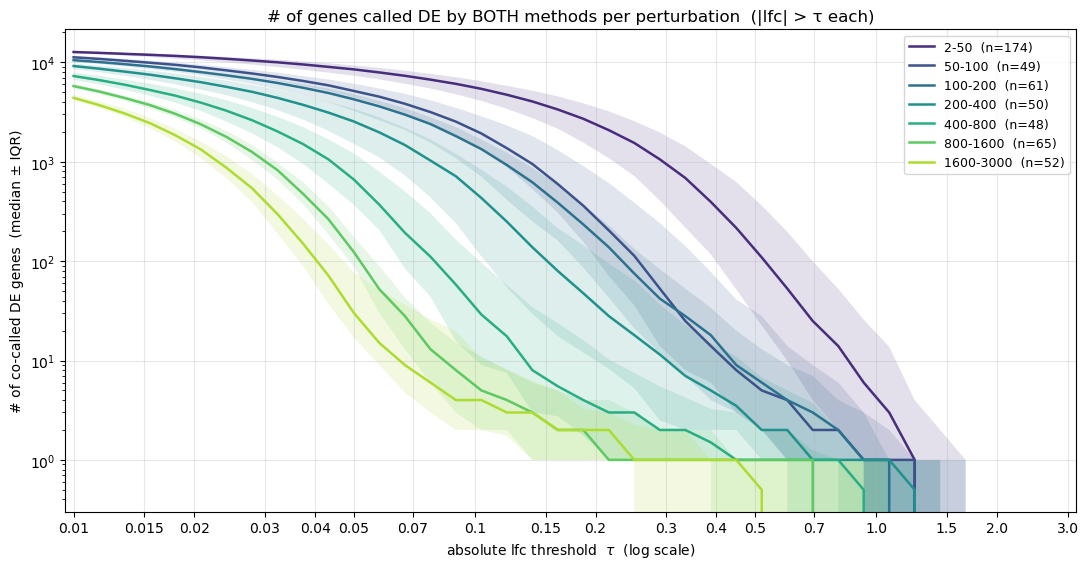

In [13]:
# --- Intersection (both methods call the same gene DE at τ) ---
fig, ax = plt.subplots(figsize=(11, 5.8))
plot_n_sig_vs_threshold(
    n_sig_long, value_col="n_intersection", ax=ax,
    ylabel="# of co-called DE genes  (median \u00b1 IQR)",
    title="# of genes called DE by BOTH methods per perturbation  (|lfc| > τ each)",
    logy=True,
)
fig.tight_layout(); plt.show()